We're now going to classify galaxy vs quasars in the Sloan Digital Sky Survey.

- Create arrays for the u-g, g-r, r-i, and i-z colors. Also create an array with the class labels where galaxy=0 and quasar=1.
- Classify the dataset against the target label.
- Try some of the classification methods we've seen so far and evaluate the performance using the ROC curve.
- Remember to split the dataset into training and validation...

- Try using different colors (a subset of them first, than all together). Which is the most important feature?
- What are the colors that better satisfy or invalidate the "Naive" assumption of independence between the attributes?


In [241]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd

data = pd.read_csv('../solutions/galaxyquasar.csv')#, allow_pickle=True)
print(data.columns)
print(data.iloc[0])
from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder().fit(data['class'].to_numpy())
data['class'] = LE.transform(data['class'].to_numpy())# QSO = 1, Galaxy = 0

data['u-g'] = data['u']-data['g']
data['g-r'] = data['g']-data['r']
data['r-i'] = data['r']-data['i']
data['i-z'] = data['i']-data['z']

Index(['u', 'g', 'r', 'i', 'z', 'class', 'z1', 'zerr'], dtype='object')
u        18.97213
g        18.53676
r         18.5828
i        18.34936
z        18.29215
class         QSO
z1       0.522819
zerr     0.000155
Name: 0, dtype: object


The SDSS bands are roughly in the optical and NIR band of the EM spectrum. If I had to pick two colors, I would go for the $i-z$ and $u-g$ ones, as they are the most different. "Red" is usually a good indicator of a galactic stellar population, while going towards the "blue" color we are examining high-energy astrophysical phenomena.

First of all, something that could help is the redshift!

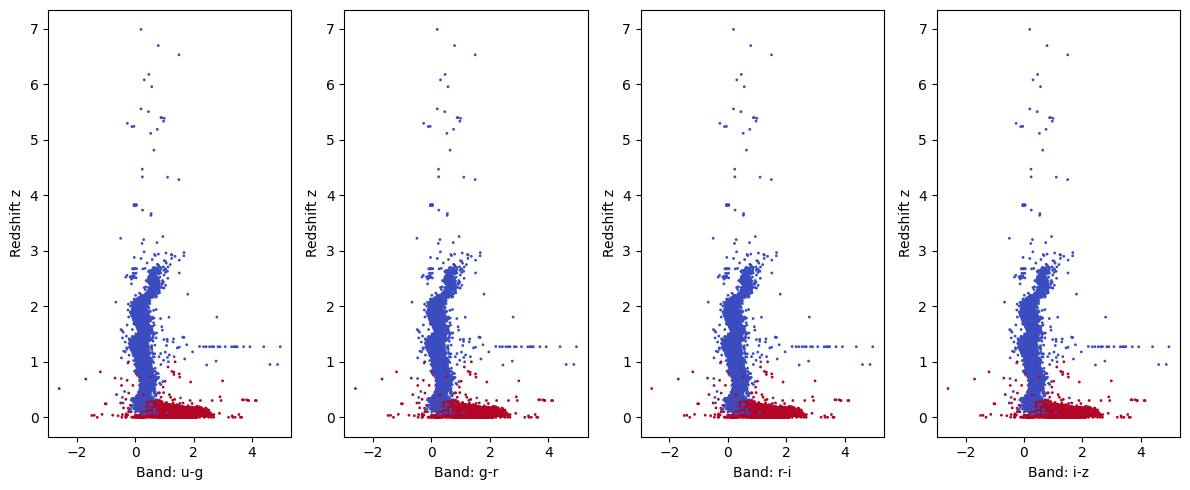

In [242]:
fig, axs = plt.subplots(1, 4, tight_layout=True, figsize=(12,5))
for i, col in enumerate(['u-g', 'g-r', 'r-i', 'i-z']):
    axs[i].scatter(data['u-g'], data['z1'], s=1, c=data['class'], cmap='coolwarm_r')
    axs[i].set_xlabel('Band: ' + col)
    axs[i].set_ylabel('Redshift z')

Ok, this is already helpful. Whenever I want to discriminate between a galaxy (red) and a QSO (blue), I can take the redshift into account: if it's at high-z, SDSS can not detect anything but a QSO. Therefore, "any" classifier will do the job at high z.

But how can I discern between the two when $z \leq 1$? Let's start by analyzing the data, as I see some "weird" lines in the scatterplot.

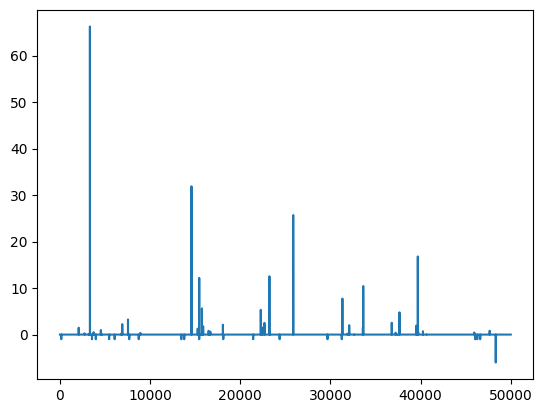

In [243]:
from astropy.visualization import hist
# _ = hist(data['zerr'], bins=200)
plt.plot(np.arange(len(data['zerr'])), data['zerr'])

Ok, something is definetly wrong. A large error on the redshift is not necessarily bad, but some entries have negative errors and I should probably discard them.

50000
103
49534


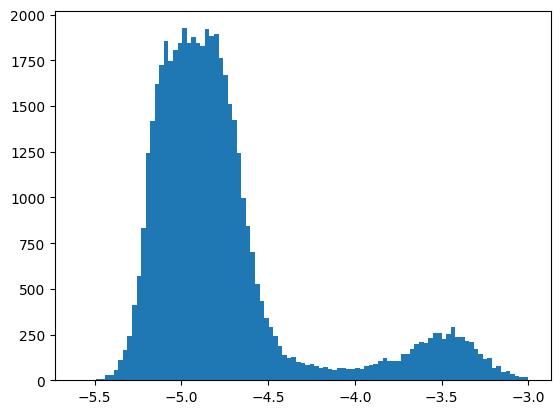

In [244]:
print(np.shape(data)[0])
data = data[data['zerr']>0]
print(len(data['zerr'][data['zerr']>1e-3]))
print(len(data['zerr'][data['zerr']<1e-3]))
_ = hist(np.log10(data['zerr']), bins=np.linspace(-5.6, -3, 100))

I know it's a bit unphysical, but for the sake of a cleaner dataset I'd discard less than 1% of it. Let's plot the data again!

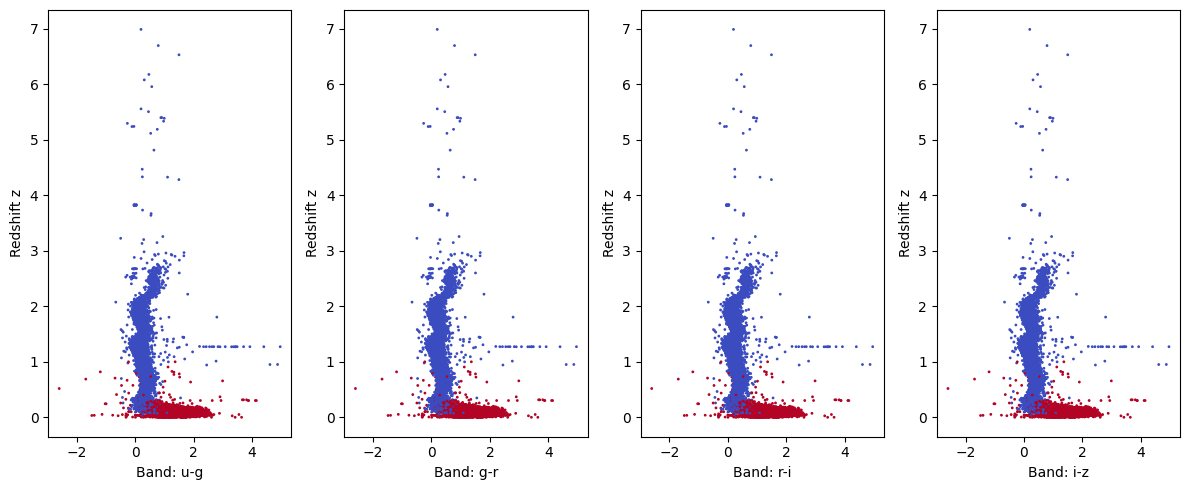

In [245]:
fig, axs = plt.subplots(1, 4, tight_layout=True, figsize=(12,5))
for i, col in enumerate(['u-g', 'g-r', 'r-i', 'i-z']):
    axs[i].scatter(data['u-g'], data['z1'], s=1, c=data['class'], cmap='coolwarm_r')
    axs[i].set_xlabel('Band: ' + col)
    axs[i].set_ylabel('Redshift z')

Well... that did not help a lot. One thing is certain, however: that is, the errors on the redshift can safely be neglected in this analysis. Let's therefore restrict our analysis to the four colors and the redshift, with our 0-1 labels, on the "trimmed" dataset.

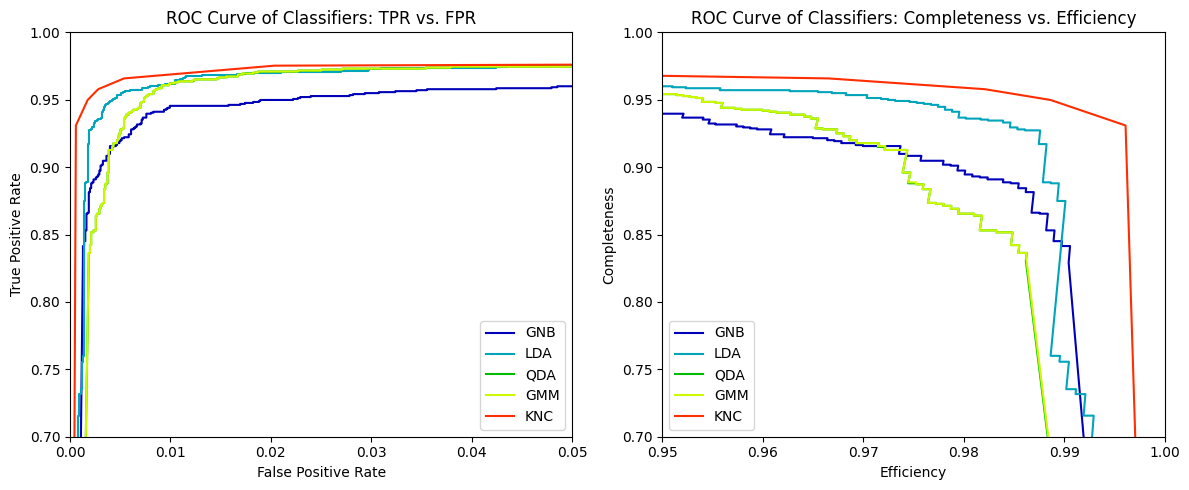

In [246]:
tData = data[['u-g', 'g-r', 'r-i', 'i-z', 'z1']]
yData = data['class']
from sklearn.model_selection import train_test_split as TTS
xTrain, xTest, yTrain, yTest = TTS(tData.to_numpy(), yData.to_numpy(), test_size=0.2)

from sklearn.naive_bayes import GaussianNB as GNB
from sklearn.neighbors import KNeighborsClassifier as KNC
from astroML.classification import GMMBayes as GMM
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

Classifiers = [GNB(), LDA(), QDA(), GMM(), KNC()]
Labels      = ['GNB', 'LDA', 'QDA', 'GMM', 'KNC']
from astroML.utils import completeness_contamination
from sklearn.metrics import precision_recall_curve, roc_curve

import seaborn as sns
fig, axs = plt.subplots(1,2, figsize=(12,5), tight_layout=True)
Colors = sns.color_palette('nipy_spectral', as_cmap=False, n_colors=len(Labels))
for clf, lab, col in zip(Classifiers, Labels, Colors):
    #for nColors in [1,2,3,4]:
    clf.fit(xTrain, yTrain)
    yProb = clf.predict_proba(xTest) [:,1]
    yPred = clf.predict(xTest)
    # completeness, contamination = completeness_contamination(yPred, yTest)
    fpr, tpr, thresh = roc_curve(yTest, yProb)
    axs[0].plot(fpr, tpr, c=col, label=lab)
    
    Completeness = np.zeros_like(thresh)
    Contamination= np.zeros_like(thresh)
    for i, t in enumerate(thresh):
        yPred = (yProb >= t)
        Completeness[i], Contamination[i] = completeness_contamination(yPred, yTest)
    Efficiency = 1-Contamination
    axs[1].plot(Efficiency, Completeness, label=lab, c=col)
    
for ax in axs: ax.set_ylim(0.7, 1.0)
axs[0].set_xlim(0.00, 0.05)
axs[1].set_xlim(0.95, 1.00)

axs[0].set_title('ROC Curve of Classifiers: TPR vs. FPR')
axs[0].set_xlabel('False Positive Rate')
axs[0].set_ylabel('True Positive Rate')

axs[1].set_title('ROC Curve of Classifiers: Completeness vs. Efficiency')
axs[1].set_xlabel('Efficiency')
axs[1].set_ylabel('Completeness')

axs[0].legend(loc='lower right')
axs[1].legend(loc='lower left')

Preliminary conclusions: 

- the Gaussian Naive Baies performs as the "worst" classifier in the group. On the other hand, a K-nearest-neighbors classivier is outperforming everyone else!
- unlike other completeness vs. efficiency curves, this dataset and classifier combination seems to be performing really well. In fact, it happens that one has many curves with low efficiency vs. completeness regimes.

This result is, however, coming from a fit on the FULL dataset. Let's check what the BEST classifier in the group does, when I change the number (and combination!) of colors in the fit.

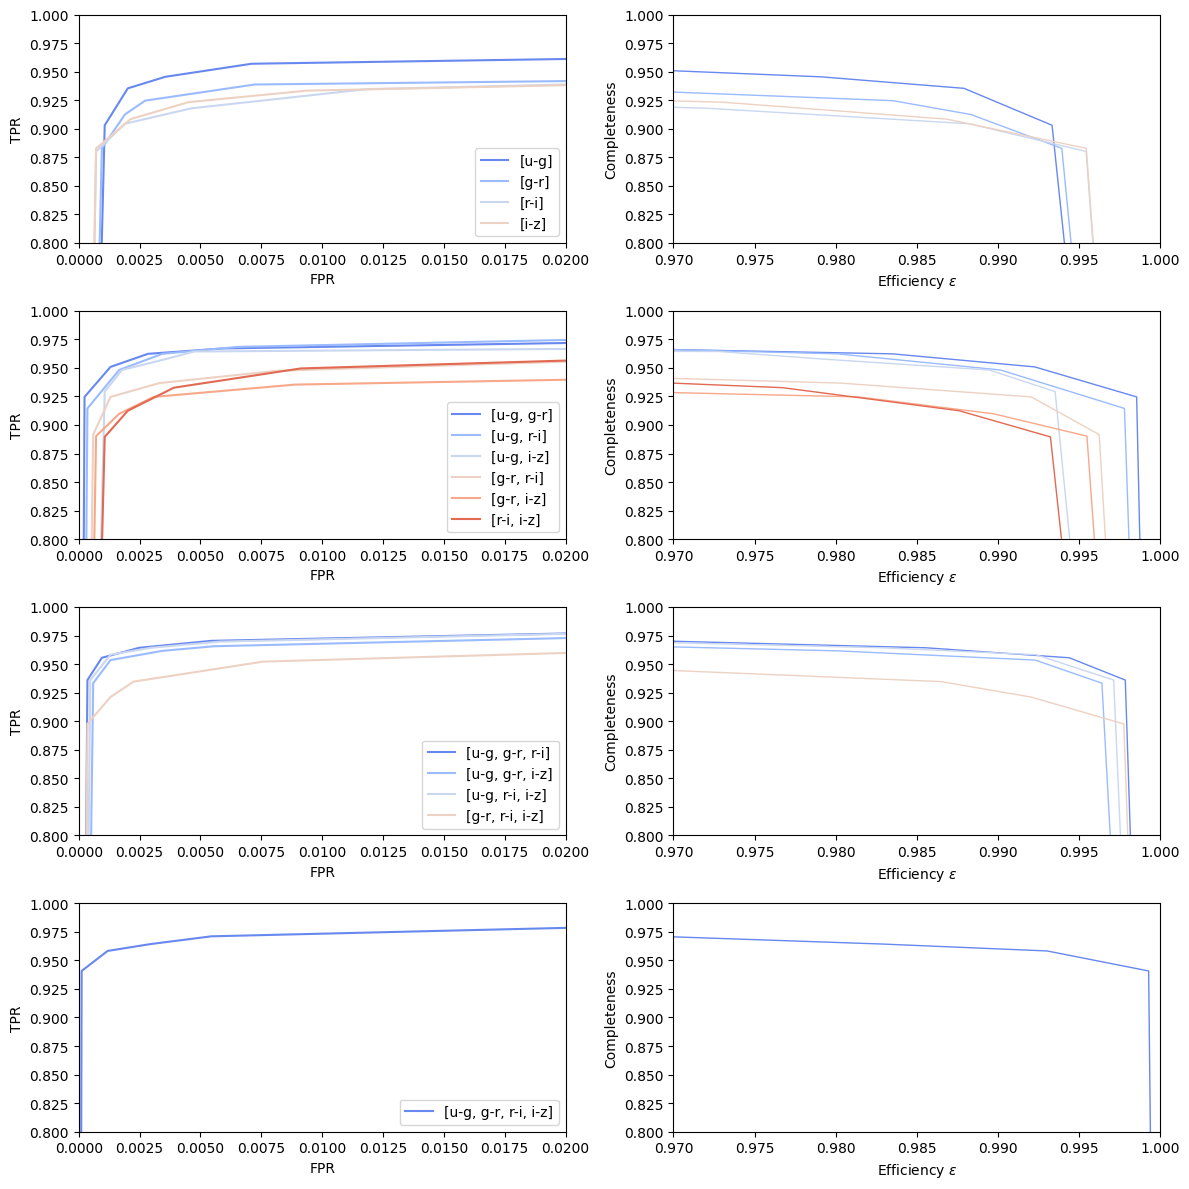

In [247]:
tData = data[['u-g', 'g-r', 'r-i', 'i-z', 'z1']]
yData = data['class']
xTrain, xTest, yTrain, yTest = TTS(tData.to_numpy(), yData.to_numpy(), test_size=0.2)

fig, axs = plt.subplots(4, 2, figsize=(12,12), tight_layout=True)

#Palettes = [_, _, 'Reds', 'Blues', 'binary']
from itertools import combinations
for r in [1, 2, 3, 4]:
    combo = list(combinations(iterable=[0,1,2,3], r=r)) 
    Palette = sns.color_palette('coolwarm', as_cmap=False, n_colors=6)
#    print(tData.columns.to_numpy()[combo])
#    print(combo)
    for j, c in enumerate(combo):
        clf = KNC()
        Slice = np.array([*c, -1]).ravel()
#        print(Slice)
        label = '['
        for name in tData.columns.to_numpy()[Slice[:-1]]: label = label+name+', '
        label = label[:-2]+']'
        clf.fit(xTrain[:, Slice], yTrain)
        yProb = clf.predict_proba(xTest[:, Slice]) [:,1]
        yPred = clf.predict(xTest[:, Slice])
        fpr, tpr, thresh = roc_curve(yTest, yProb)
        axs[r-1, 0].plot(fpr, tpr, c=Palette[j], label=label)
    
        Completeness = np.zeros_like(thresh)
        Contamination= np.zeros_like(thresh)
        for i, t in enumerate(thresh):
            yPred = (yProb >= t)
            Completeness[i], Contamination[i] = completeness_contamination(yPred, yTest)
        Efficiency = 1-Contamination
        axs[r-1, 1].plot(Efficiency, Completeness, label=label, c=Palette[j], lw=1)
   
for ax in axs[:, 0]: 
    ax.set_ylim(0.80, 1.00)
    ax.set_xlim(0.00, 0.02)
for ax in axs[:, 1]:
    ax.set_xlim(0.97, 1.00)
    ax.set_ylim(0.80, 1.00)

for ax in axs[:, 0]:
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')

for ax in axs[:, 1]:
    ax.set_xlabel(r'Efficiency $\epsilon$')
    ax.set_ylabel('Completeness')
for ax in axs[:, 0]:
    ax.legend(loc='lower right')
    #ax.legend(loc='lower left')

Qualitative conclusions: the presence of the 'u-g' band improves the KNC performance. In fact, one can see that its absence alters the ROC curve and drags it downwards. Given that a QSO is a highly energetic phenomenon, it may feature a more distinct emission in the high-energy part of the spectrum.

CRUCIALLY, it is the redshift indication that *really* helps the classifier! In fact, if I REMOVE that, the performance worsens significantly:

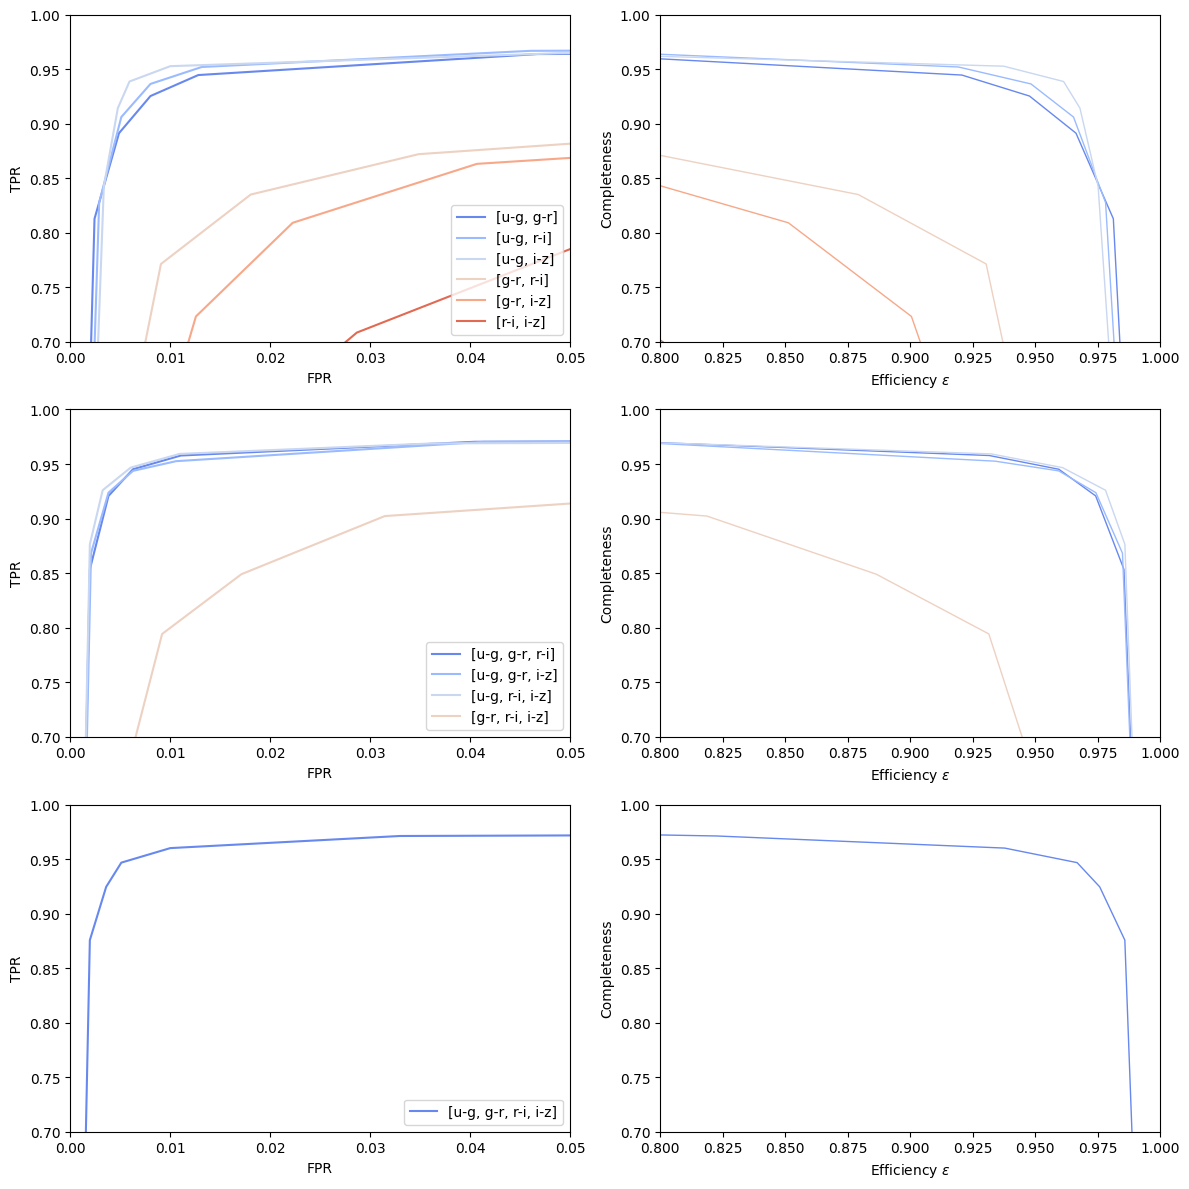

In [248]:
tData = data[['u-g', 'g-r', 'r-i', 'i-z']]
yData = data['class']
xTrain, xTest, yTrain, yTest = TTS(tData.to_numpy(), yData.to_numpy(), test_size=0.2)

fig, axs = plt.subplots(3, 2, figsize=(12,12), tight_layout=True)

#Palettes = [_, _, 'Reds', 'Blues', 'binary']
from itertools import combinations
for r in [2, 3, 4]:
    combo = list(combinations(iterable=[0,1,2,3], r=r)) 
    Palette = sns.color_palette('coolwarm', as_cmap=False, n_colors=6)
#    print(tData.columns.to_numpy()[combo])
#    print(combo)
    for j, c in enumerate(combo):
        clf = KNC()
        Slice = np.array([*c]).ravel()
#        print(Slice)
        label = '['
        for name in tData.columns.to_numpy()[Slice[:]]: label = label+name+', '
        label = label[:-2]+']'
        clf.fit(xTrain[:, Slice], yTrain)
        yProb = clf.predict_proba(xTest[:, Slice]) [:,1]
        yPred = clf.predict(xTest[:, Slice])
        fpr, tpr, thresh = roc_curve(yTest, yProb)
        axs[r-2, 0].plot(fpr, tpr, c=Palette[j], label=label)
    
        Completeness = np.zeros_like(thresh)
        Contamination= np.zeros_like(thresh)
        for i, t in enumerate(thresh):
            yPred = (yProb >= t)
            Completeness[i], Contamination[i] = completeness_contamination(yPred, yTest)
        Efficiency = 1-Contamination
        axs[r-2, 1].plot(Efficiency, Completeness, label=label, c=Palette[j], lw=1)
   
for ax in axs[:, 0]: 
    ax.set_ylim(0.70, 1.00)
    ax.set_xlim(0.00, 0.05)
for ax in axs[:, 1]:
    ax.set_xlim(0.80, 1.00)
    ax.set_ylim(0.70, 1.00)

#axs[0,0].set_title('ROC Curve of Classifiers: TPR vs. FPR')
for ax in axs[:, 0]:
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')

#axs[0,1].set_title('ROC Curve of Classifiers: Completeness vs. Efficiency')
for ax in axs[:, 1]:
    ax.set_xlabel(r'Efficiency $\epsilon$')
    ax.set_ylabel('Completeness')
for ax in axs[:, 0]:
    ax.legend(loc='lower right')
    #ax.legend(loc='lower left')

Ok, I can draw some conclusions on the combination of colors, at least for this classifier. _Regardless of the measured redshift_, the $g-r \oplus  r-i$ combination is the worst to use to classify the objects, while the presence of the $u-g$ band is likely the best feature to look for.

---

If instead I can also add the redshift feature in my classifier, that instantly becomes the most important feature in the full dataset. STILL, at low-z it is probably MORE important to examine the $u-g$ color.

---

So far, I have only tested each classifier with its "standard" parameters. One could also verify how each classifier performance would change by tweaking its initial configuration. By heart, I feel that by increasing the number of kNeighbors my classifier could increase its completeness, but the computational cost could increase significantly. One solution could be to run a PCA and run the classifier on that, to reduce the computational costs.

(49637, 5)


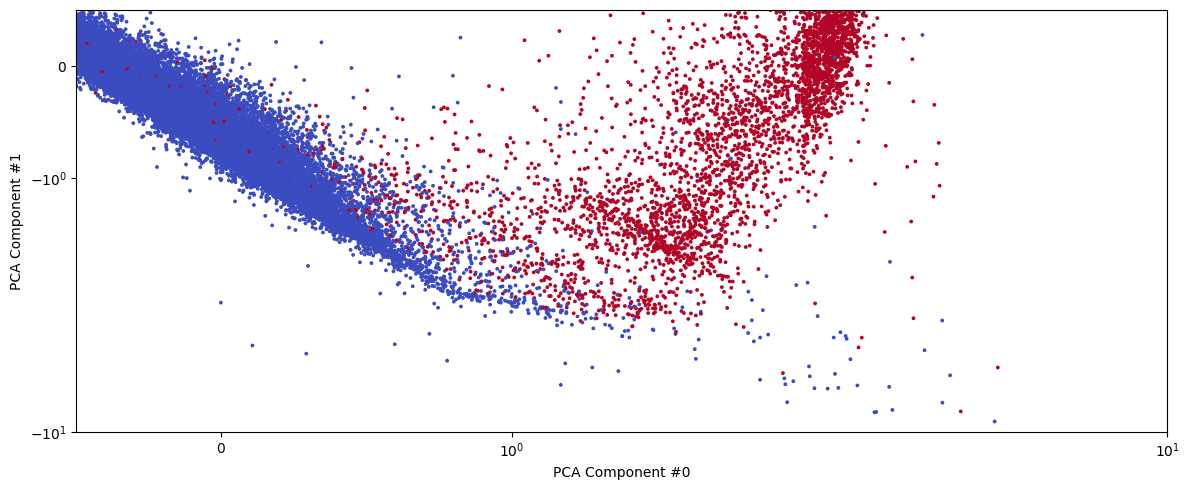

In [273]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

PCA = PCA()#n_components=2)

lowZ = ( data['z1']<1 )
data_2d = PCA.fit_transform(data[['u-g', 'g-r', 'r-i', 'i-z', 'z1']].to_numpy())
Scaler = StandardScaler()
data_2d = Scaler.fit_transform(X=data_2d)
print(np.shape(data_2d))
plt.figure(figsize=(12,5), tight_layout=True)
plt.scatter(data_2d[:,0], data_2d[:,1], c=data['class'], s=3, cmap='coolwarm')
plt.yscale('symlog')
plt.xscale('symlog')
plt.xlabel('PCA Component #0')
plt.ylabel('PCA Component #1')
plt.xlim(-0.5, 10)
_ = plt.ylim(-10, 0.5)

This is a very zoomed-in version of a PCA of the original dataset, which was pre-processed ( thus without $\approx 400$ 'spurious' values). 

Indeed, a classifier may struggle with the objects in the middle of the distribution, but most of the QSO and Galaxy data are clearly distinguishable in the two PCA components I am showing!